<a href="https://colab.research.google.com/github/22wh1a04c6/Data-Science-Task/blob/main/Loan_approval_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval Prediction

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [35]:
#load the data
df=pd.read_csv("loan_data.csv")

# EDA

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [37]:
#handle outliers in person age column
df=df[df["person_age"]<=100]

# Data Visualisation

<Axes: xlabel='loan_status', ylabel='Count'>

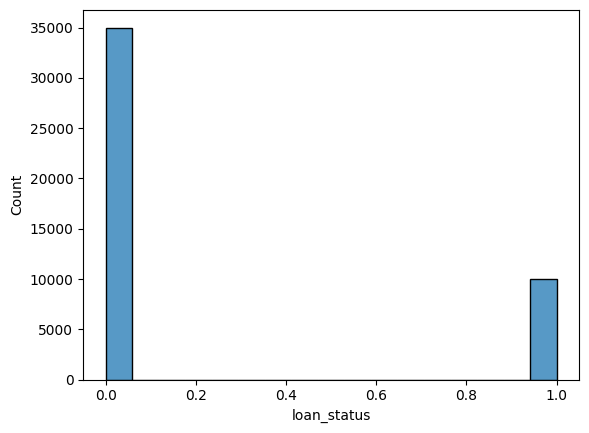

In [38]:
sns.histplot(x="loan_status",data=df)

<Axes: xlabel='person_gender', ylabel='count'>

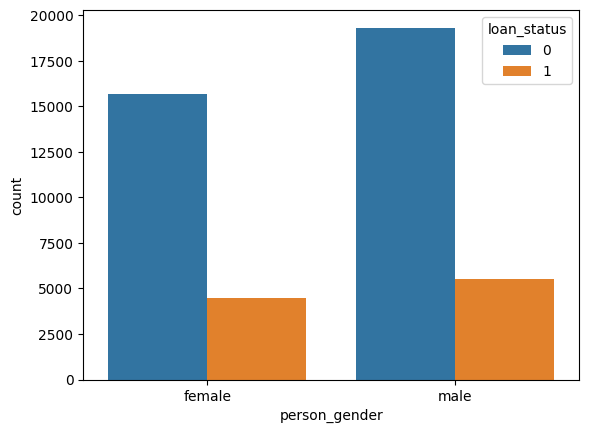

In [39]:
sns.countplot(x="person_gender",data=df,hue="loan_status")

<Axes: xlabel='person_age', ylabel='Count'>

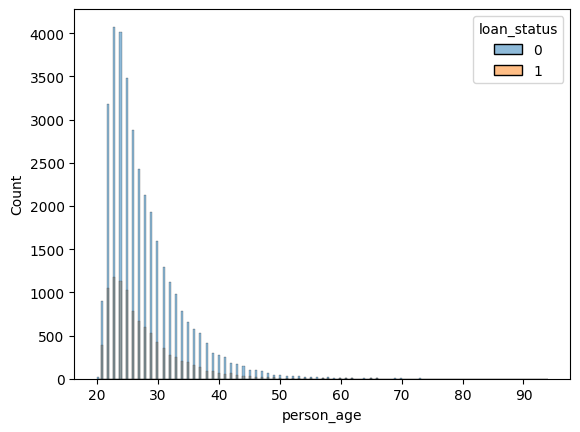

In [40]:
sns.histplot(x="person_age",data=df,hue="loan_status")

<Axes: xlabel='person_education', ylabel='count'>

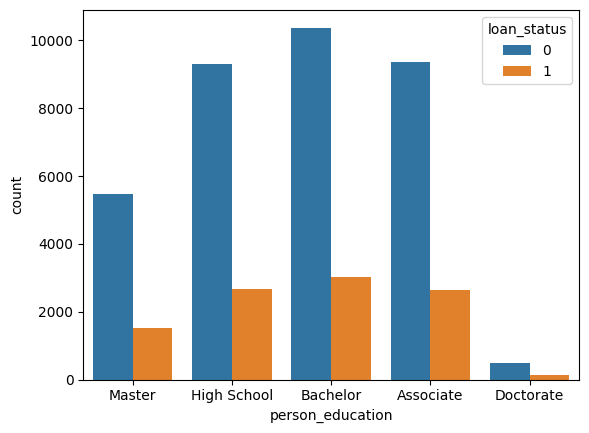

In [41]:
sns.countplot(x="person_education",data=df,hue="loan_status")

In [42]:
#with which avg income they are getting loans
df.groupby("loan_status")["person_income"].mean()

,person_income
loan_status,
0,85630.263567
1,59886.096900


**Insights**- even if you have less income you may get more loans

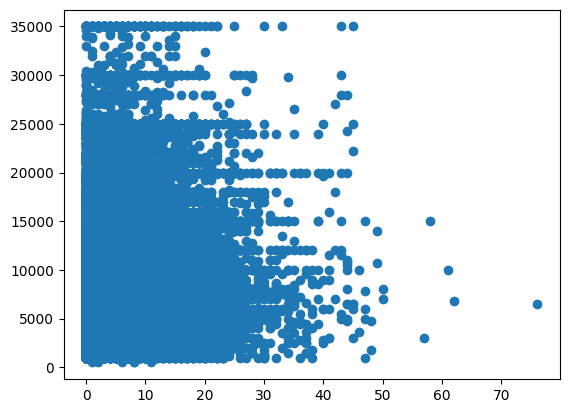

In [43]:
plt.scatter(df["person_emp_exp"],df["loan_amnt"])

<Axes: xlabel='credit_score', ylabel='Count'>

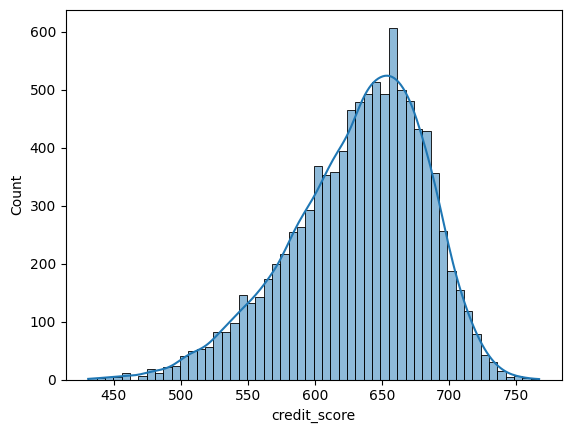

In [44]:
sns.histplot(x="credit_score",data=df[df["loan_status"]==1],kde=True)

<Axes: >

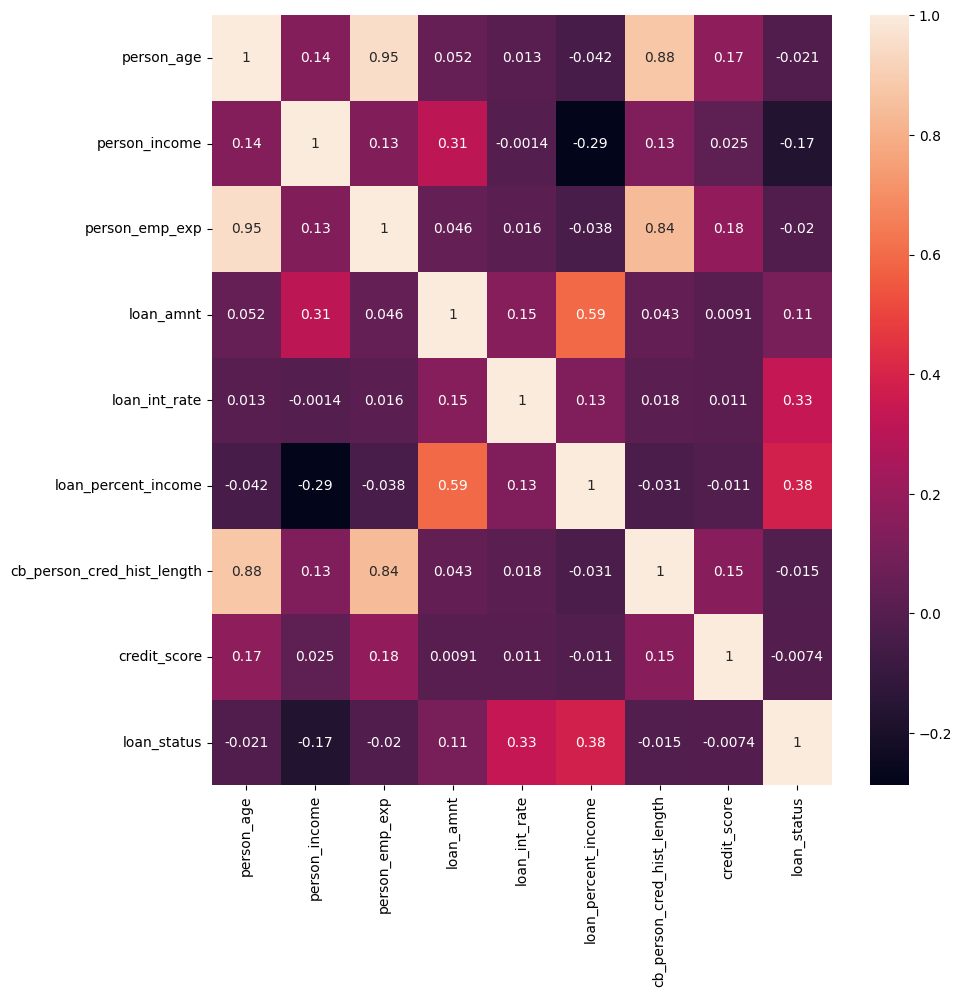

In [45]:
numeric_columns=[col for col in df.columns if df[col].dtype!=object]
data=df[numeric_columns].corr()
plt.figure(figsize=(10,10))
sns.heatmap(data,annot=True)

# Model Training

In [57]:
#encoding
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
for col in df.columns:
  if df[col].dtype==object:
    df[col]=encoder.fit_transform(df[col])

In [58]:
#dividing the data into input and output
x=df.drop("loan_status",axis=1)
y=df["loan_status"]

In [59]:
#splitting the data for training and testing
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [60]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
xtrain=scaler.fit_transform(xtrain)
xtest=scaler.transform(xtest)

In [61]:
model=SVC()
model.fit(xtrain,ytrain)

SVC()

# Model Evaluation and tuning

In [62]:
ypred=model.predict(xtest)
ypred

array([1, 0, 0, ..., 1, 0, 1])

In [63]:
confusion_matrix(ytest,ypred)

array([[10044,   446],
       [  792,  2216]])

In [64]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94     10490
           1       0.83      0.74      0.78      3008

    accuracy                           0.91     13498
   macro avg       0.88      0.85      0.86     13498
weighted avg       0.91      0.91      0.91     13498



In [65]:
print("Training eff:",model.score(xtrain,ytrain))
print("Testing eff:",model.score(xtest,ytest))

Training eff: 0.9132560723924432
Testing eff: 0.9082827085494147


In [67]:
new_data=df.iloc[0:1,:-1]
new_data=scaler.transform(new_data)  #here again we are doing scaling because we scaled df and for new data also we should do scaling
pred=model.predict(new_data)[0]
if pred==0:
  print("loan not approved")
else:
  print("loan approved")

loan approved
